# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "sf6"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[3.17 3.183333333333333 3.1966666666666663 ... 3.565 3.64 3.64] [3.17 3.183333333333333 3.1898181818181817 ... 3.5224347826086957 3.581217391304348 3.64] [3.17 3.179909090909091 3.1992608695652174 ... 3.5325 3.5922222222222224 3.64] [3.17 3.206428571428572 3.242857142857143 ... 3.5444444444444447 3.6041666666666665 3.64] [3.17 3.183333333333333 3.208214285714286 ... 3.5563888888888893 3.6161111111111115 3.64] [3.17 3.183333333333333 3.1966666666666663 ... 3.5683333333333334 3.628055555555556 3.64]] [[3.23 3.212666666666667 3.195333333333333 ... 3.5286666666666666 3.5499999999999994 3.674] [3.23 3.2126666666666663 3.2329090909090907 ... 3.57904347826087 3.6265217391304345 3.674] [3.23 3.231454545454546 3.285826086956522 ... 3.5500000000000003 3.605111111111111 3.674] [3.23 3.2580000000000005 3.2859999999999996 ... 3.5362222222222224 3.591333333333333 3.674] [3.23 3.212666666666667 3.218 ... 3.5224444444444445 3.577555555555555 3.674] [3.23 3.212666666666667 3.195333333333333 ... 3.5086666666666666 3.5637777777777777 3.674]] [[3.148 3.1766666666666667 3.2053333333333334 ... 3.570666666666667 3.686 3.6] [3.148 3.1766666666666663 3.1969090909090907 ... 3.7133333333333334 3.6566666666666667 3.6] [3.148 3.1724545454545456 3.220142857142857 ... 3.5085 3.568888888888889 3.6] [3.148 3.2123636363636363 3.2767272727272725 ... 3.5377777777777775 3.5981666666666663 3.6] [3.148 3.1766666666666667 3.223181818181818 ... 3.5670555555555556 3.6274444444444445 3.6] [3.148 3.1766666666666667 3.205333333333333 ... 3.5963333333333334 3.656722222222222 3.6]] ... [[11.293 11.3092 11.329 ... 11.8 11.761 11.77825] [11.293 11.308 11.38557142857143 ... 11.827666666666667 11.804333333333334 11.781] [11.293 11.329294117647057 11.386882352941175 ... 11.79 11.78275 11.775500000000001] [11.293 11.363374999999998 11.43375 ... 11.833333333333334 11.801666666666666 11.77] [11.293 11.311599999999999 11.3566875 ... 11.822222222222221 11.788111111111112 11.77275] [11.293 11.3104 11.3302 ... 11.811111111111112 11.774555555555555 11.775500000000001]] [[11.308 11.331333333333333 11.354666666666668 ... 11.850999999999999 11.826 11.846499999999999] [11.308 11.331333333333333 11.359272727272726 ... 11.846333333333334 11.844666666666667 11.843] [11.308 11.333636363636364 11.375384615384615 ... 11.901 11.875499999999999 11.85] [11.308 11.376750000000001 11.4455 ... 11.869 11.863 11.857] [11.308 11.331333333333333 11.377375 ... 11.862999999999998 11.850666666666667 11.8535] [11.308 11.331333333333333 11.354666666666667 ... 11.857 11.838333333333333 11.85]] [[11.324 11.397642857142856 11.471285714285713 ... 11.8425 11.844 11.844] [11.324 11.397642857142856 11.471285714285713 ... 11.868 11.843999999999998 11.844] [11.324 11.397642857142857 11.471285714285713 ... 11.88 11.844 11.844] [11.324 11.388220588235296 11.452441176470588 ... 11.870625 11.844 11.844] [11.324 11.397642857142857 11.471285714285713 ... 11.86125 11.844 11.844] [11.324 11.397642857142857 11.471285714285713 ... 11.851875 11.844 11.844]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[3.17 3.183333333333333 3.1966666666666663 ... 3.565 3.64 3.64] [3.17 3.183333333333333 3.1898181818181817 ... 3.5224347826086957 3.581217391304348 3.64] [3.17 3.179909090909091 3.1992608695652174 ... 3.5325 3.5922222222222224 3.64] [3.17 3.206428571428572 3.242857142857143 ... 3.5444444444444447 3.6041666666666665 3.64] [3.17 3.183333333333333 3.208214285714286 ... 3.5563888888888893 3.6161111111111115 3.64] [3.17 3.183333333333333 3.1966666666666663 ... 3.5683333333333334 3.628055555555556 3.64]] [[3.23 3.212666666666667 3.195333333333333 ... 3.5286666666666666 3.5499999999999994 3.674] [3.23 3.2126666666666663 3.2329090909090907 ... 3.57904347826087 3.6265217391304345 3.674] [3.23 3.231454545454546 3.285826086956522 ... 3.5500000000000003 3.605111111111111 3.674] [3.23 3.2580000000000005 3.2859999999999996 ... 3.5362222222222224 3.591333333333333 3.674] [3.23 3.212666666666667 3.218 ... 3.5224444444444445 3.577555555555555 3.674] [3.23 3.212666666666667 3.195333333333333 ... 3.5086666666666666 3.5637777777777777 3.674]] [[3.148 3.1766666666666667 3.2053333333333334 ... 3.570666666666667 3.686 3.6] [3.148 3.1766666666666663 3.1969090909090907 ... 3.7133333333333334 3.6566666666666667 3.6] [3.148 3.1724545454545456 3.220142857142857 ... 3.5085 3.568888888888889 3.6] [3.148 3.2123636363636363 3.2767272727272725 ... 3.5377777777777775 3.5981666666666663 3.6] [3.148 3.1766666666666667 3.223181818181818 ... 3.5670555555555556 3.6274444444444445 3.6] [3.148 3.1766666666666667 3.205333333333333 ... 3.5963333333333334 3.656722222222222 3.6]] ... [[11.293 11.3092 11.329 ... 11.8 11.761 11.77825] [11.293 11.308 11.38557142857143 ... 11.827666666666667 11.804333333333334 11.781] [11.293 11.329294117647057 11.386882352941175 ... 11.79 11.78275 11.775500000000001] [11.293 11.363374999999998 11.43375 ... 11.833333333333334 11.801666666666666 11.77] [11.293 11.311599999999999 11.3566875 ... 11.822222222222221 11.788111111111112 11.77275] [11.293 11.3104 11.3302 ... 11.811111111111112 11.774555555555555 11.775500000000001]] [[11.308 11.331333333333333 11.354666666666668 ... 11.850999999999999 11.826 11.846499999999999] [11.308 11.331333333333333 11.359272727272726 ... 11.846333333333334 11.844666666666667 11.843] [11.308 11.333636363636364 11.375384615384615 ... 11.901 11.875499999999999 11.85] [11.308 11.376750000000001 11.4455 ... 11.869 11.863 11.857] [11.308 11.331333333333333 11.377375 ... 11.862999999999998 11.850666666666667 11.8535] [11.308 11.331333333333333 11.354666666666667 ... 11.857 11.838333333333333 11.85]] [[11.324 11.397642857142856 11.471285714285713 ... 11.8425 11.844 11.844] [11.324 11.397642857142856 11.471285714285713 ... 11.868 11.843999999999998 11.844] [11.324 11.397642857142857 11.471285714285713 ... 11.88 11.844 11.844] [11.324 11.388220588235296 11.452441176470588 ... 11.870625 11.844 11.844] [11.324 11.397642857142857 11.471285714285713 ... 11.86125 11.844 11.844] [11.324 11.397642857142857 11.471285714285713 ... 11.851875 11.844 11.844]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'sf6' (lon: 6, lat: 12, year: 29, month: 12)> Size: 200kB
<Quantity([[[[ 3.17        3.23        3.148      ...  3.309       3.384
     3.447     ]
   [ 3.42        3.454       3.434      ...  3.638       3.595
     3.61      ]
   [ 3.683       3.705       3.692      ...  3.872       3.888
     3.886     ]
   ...
   [10.211      10.236      10.263      ... 10.509      10.54
    10.564     ]
   [10.587      10.609      10.642      ... 10.888      10.907
    10.928     ]
   [10.953      10.984      11.016      ... 11.266      11.293
    11.308     ]]

  [[ 3.18333333  3.21266667  3.17666667 ...  3.32533333  3.38266667
     3.43133333]
   [ 3.41433333  3.44933333  3.43466667 ...  3.61233333  3.59666667
     3.626     ]
   [ 3.68766667  3.69933333  3.689      ...  3.8772      3.8946
     3.9003    ]
...
   [10.65583333 10.68808333 10.72508333 ... 10.944      10.98716667
    11.05366667]
   [11.09166667 11.10091667 11.14425    ... 11.32333333 11.37433333
    11.41708333]
   [11.438      11.47444444 11.50811111 ... 11.70833333 11.77455556
    11.83833333]]

  [[ 3.64        3.674       3.6        ...  3.808       3.858
     3.879     ]
   [ 3.87        3.886       3.91       ...  4.017       3.995
     4.041     ]
   [ 4.089       4.079       4.148      ...  4.189       4.24
     4.289     ]
   ...
   [10.6615     10.697      10.7285     ... 10.939      10.976
    11.056     ]
   [11.09       11.088      11.1655     ... 11.331      11.385
    11.424     ]
   [11.453      11.481      11.5155     ... 11.7105     11.7755
    11.85      ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 232B 1995 1996 1997 1998 1999 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[3.17 3.23 3.148 ... 11.266 11.293 11.308] [3.183333333333333 3.212666666666667 3.1766666666666667 ... 11.27845 11.3092 11.331333333333333] [3.1966666666666663 3.195333333333333 3.2053333333333334 ... 11.286249999999999 11.329 11.354666666666668] ... [3.565 3.5286666666666666 3.570666666666667 ... 11.7395 11.8 11.850999999999999] [3.64 3.5499999999999994 3.686 ... 11.7 11.761 11.826] [3.64 3.674 3.6 ... 11.718250000000001 11.77825 11.846499999999999]] [[3.17 3.23 3.148 ... 11.266 11.293 11.308] [3.183333333333333 3.2126666666666663 3.1766666666666663 ... 11.28 11.308 11.331333333333333] [3.1898181818181817 3.2329090909090907 3.1969090909090907 ... 11.349857142857143 11.38557142857143 11.359272727272726] ... [3.5224347826086957 3.57904347826087 3.7133333333333334 ... 11.754666666666667 11.827666666666667 11.846333333333334] [3.581217391304348 3.6265217391304345 3.6566666666666667 ... 11.740333333333334 11.804333333333334 11.844666666666667] [3.64 3.674 3.6 ... 11.726 11.781 11.843]] [[3.17 3.23 3.148 ... 11.266 11.293 11.308] [3.179909090909091 3.231454545454546 3.1724545454545456 ... 11.300264705882352 11.329294117647057 11.333636363636364] [3.1992608695652174 3.285826086956522 3.220142857142857 ... 11.354794117647058 11.386882352941175 11.375384615384615] ... [3.5325 3.5500000000000003 3.5085 ... 11.7365 11.79 11.901] [3.5922222222222224 3.605111111111111 3.568888888888889 ... 11.7235 11.78275 11.875499999999999] [3.64 3.674 3.6 ... 11.7105 11.775500000000001 11.85]] [[3.17 3.23 3.148 ... 11.266 11.293 11.308] [3.206428571428572 3.2580000000000005 3.2123636363636363 ... 11.330499999999999 11.363374999999998 11.376750000000001] [3.242857142857143 3.2859999999999996 3.2767272727272725 ... 11.395 11.43375 11.4455] ... [3.5444444444444447 3.5362222222222224 3.5377777777777775 ... 11.755 11.833333333333334 11.869] [3.6041666666666665 3.591333333333333 3.5981666666666663 ... 11.725000000000001 11.801666666666666 11.863] [3.64 3.674 3.6 ... 11.695 11.77 11.857]] [[3.17 3.23 3.148 ... 11.266 11.293 11.308] [3.183333333333333 3.212666666666667 3.1766666666666667 ... 11.27535 11.311599999999999 11.331333333333333] [3.208214285714286 3.218 3.223181818181818 ... 11.3115 11.3566875 11.377375] ... [3.5563888888888893 3.5224444444444445 3.5670555555555556 ... 11.749833333333333 11.822222222222221 11.862999999999998] [3.6161111111111115 3.577555555555555 3.6274444444444445 ... 11.716666666666667 11.788111111111112 11.850666666666667] [3.64 3.674 3.6 ... 11.70275 11.77275 11.8535]] [[3.17 3.23 3.148 ... 11.266 11.293 11.308] [3.183333333333333 3.212666666666667 3.1766666666666667 ... 11.276900000000001 11.3104 11.331333333333333] [3.1966666666666663 3.195333333333333 3.205333333333333 ... 11.2847 11.3302 11.354666666666667] ... [3.5683333333333334 3.5086666666666666 3.5963333333333334 ... 11.744666666666667 11.811111111111112 11.857] [3.628055555555556 3.5637777777777777 3.656722222222222 ... 11.708333333333334 11.774555555555555 11.838333333333333] [3.64 3.674 3.6 ... 11.7105 11.775500000000001 11.85]]]
Units,ppt


### Longitudinal-mean

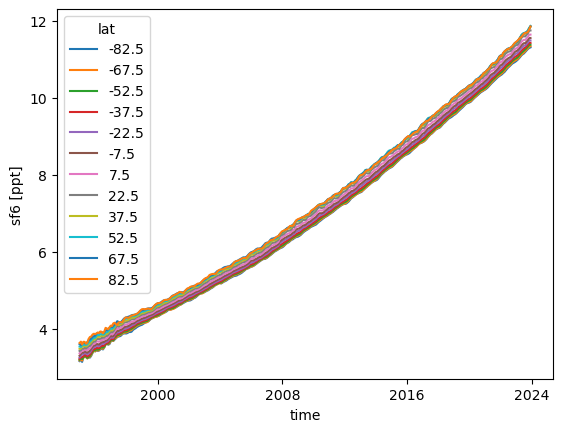

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

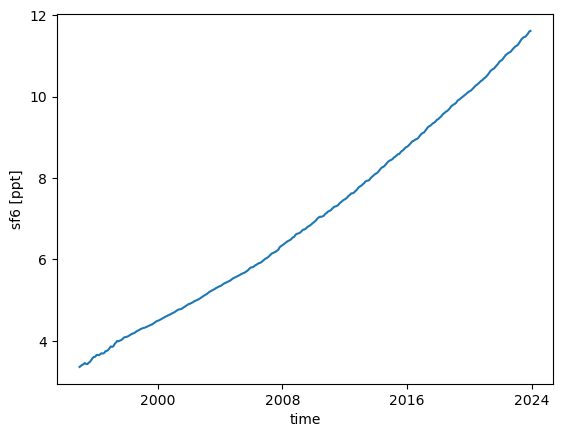

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

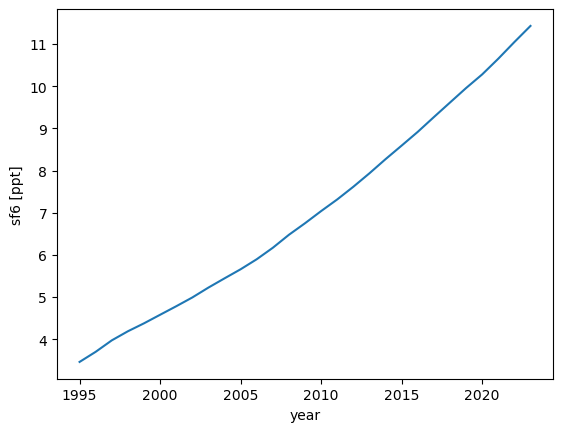

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 4kB
Dimensions:               (lat: 12, eof: 12, year: 29)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 232B 1995 1996 1997 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.4079 ... -0.05329
    principal-components  (year, eof) float64 3kB [] -0.5269 ... -9.185e-20

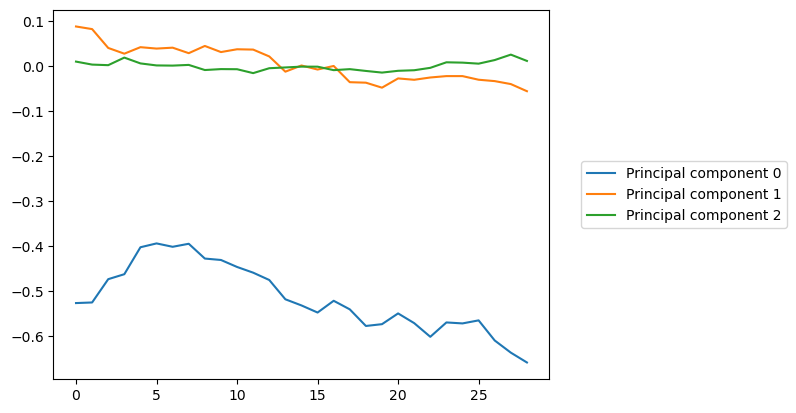

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

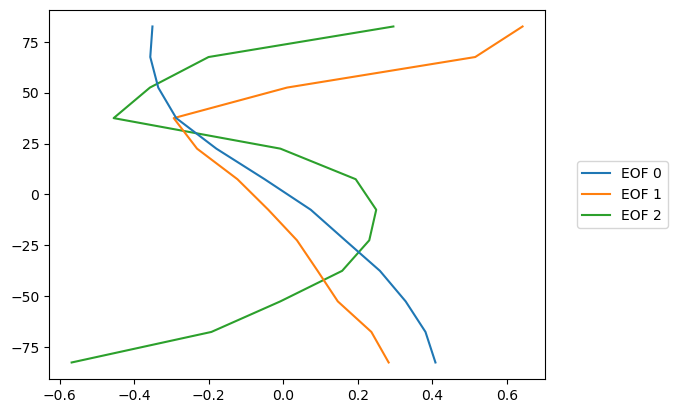

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

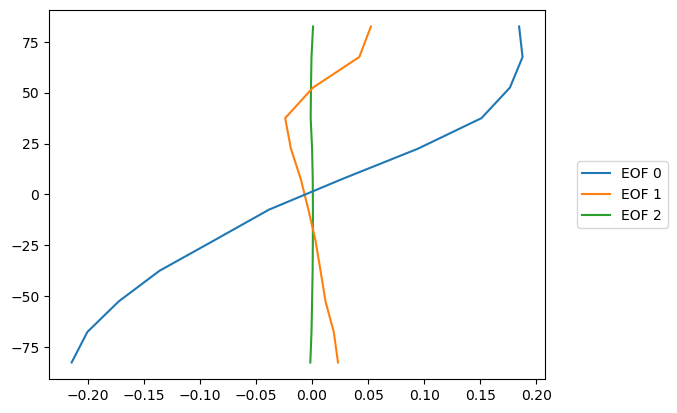

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.4079144945513143] [0.38121088006618586] [0.32803681283612063] [0.25902426734783796] [0.16591949002115422] [0.07350986459476755] [-0.05027843646848017] [-0.17966488611429515] [-0.28732054111144506] [-0.3355734244310076] [-0.3569405173005223] [-0.35110224884761926]]
Units,ppt
Magnitude,[[-0.5268536692887996] [-0.5255318825237465] [-0.47377527548868265] [-0.46274172921606177] [-0.4028843032667429] [-0.3943521096226741] [-0.4018561199394775] [-0.39513027256083033] [-0.42799276933163727] [-0.4311443693212688] [-0.44665384828639076] [-0.4593226365762061] [-0.47560397981591074] [-0.5184542882134794] [-0.5321067318215438] [-0.5478900198083761] [-0.521766020995275] [-0.5408121827770037] [-0.5777188586999328] [-0.5737321803054596] [-0.5498445217639079] [-0.5714290513260026] [-0.6017812365072408] [-0.5698882234392172] [-0.5720554051146591] [-0.5652992224480415] [-0.609971857044052] [-0.636980673918009] [-0.6588197431957152]]
Units,dimensionless


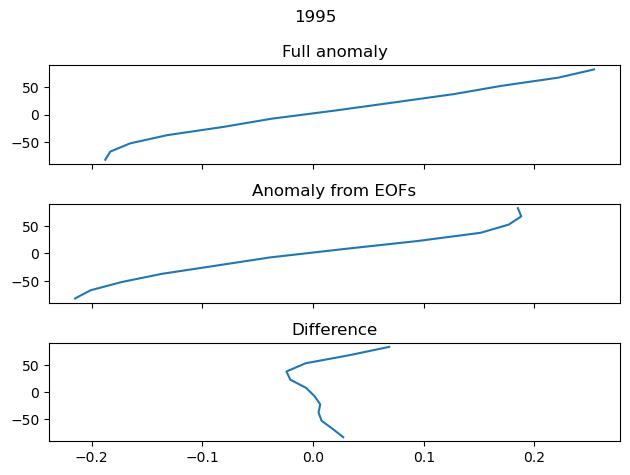

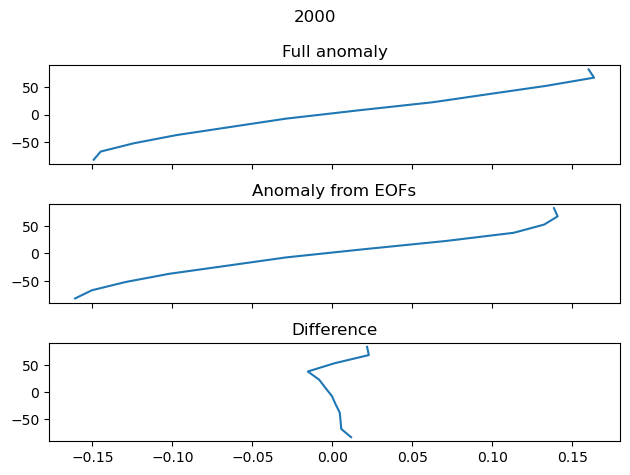

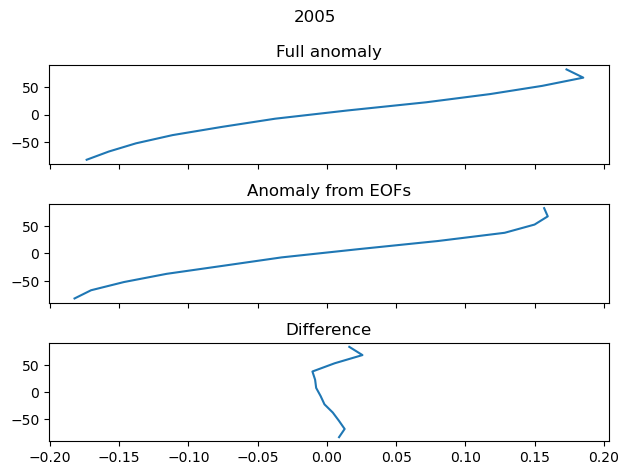

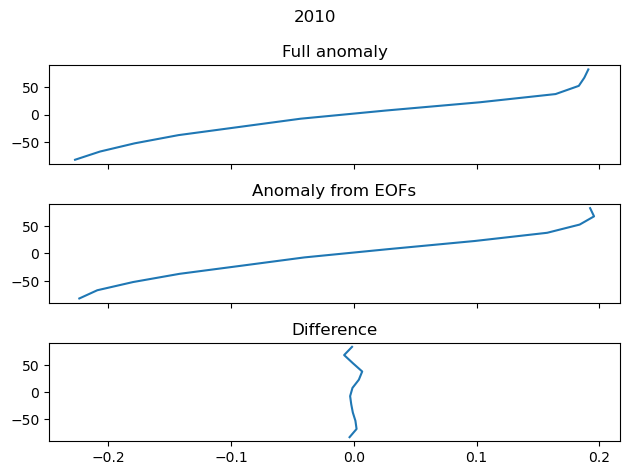

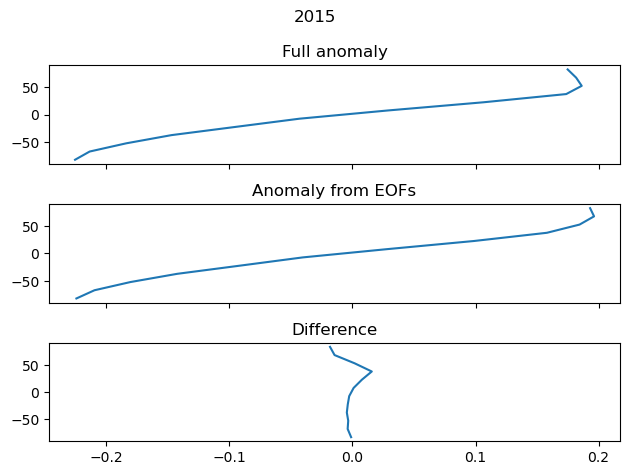

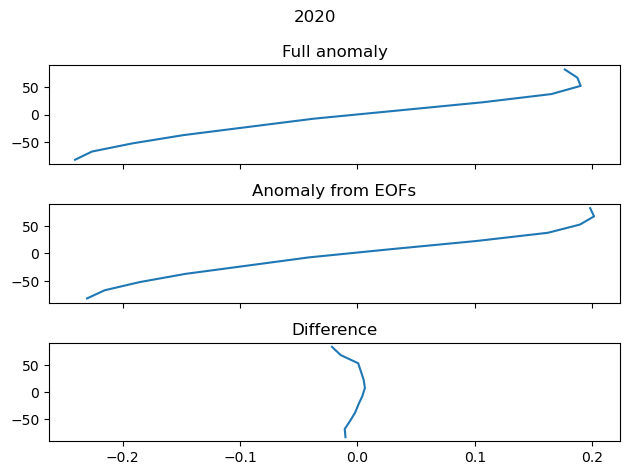

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/348 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 348/348 [00:00<00:00, 18533.42it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/348 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/348 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 348/348 [00:00<00:00, 19621.16it/s]

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/348 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 348/348 [00:00<00:00, 19318.36it/s]

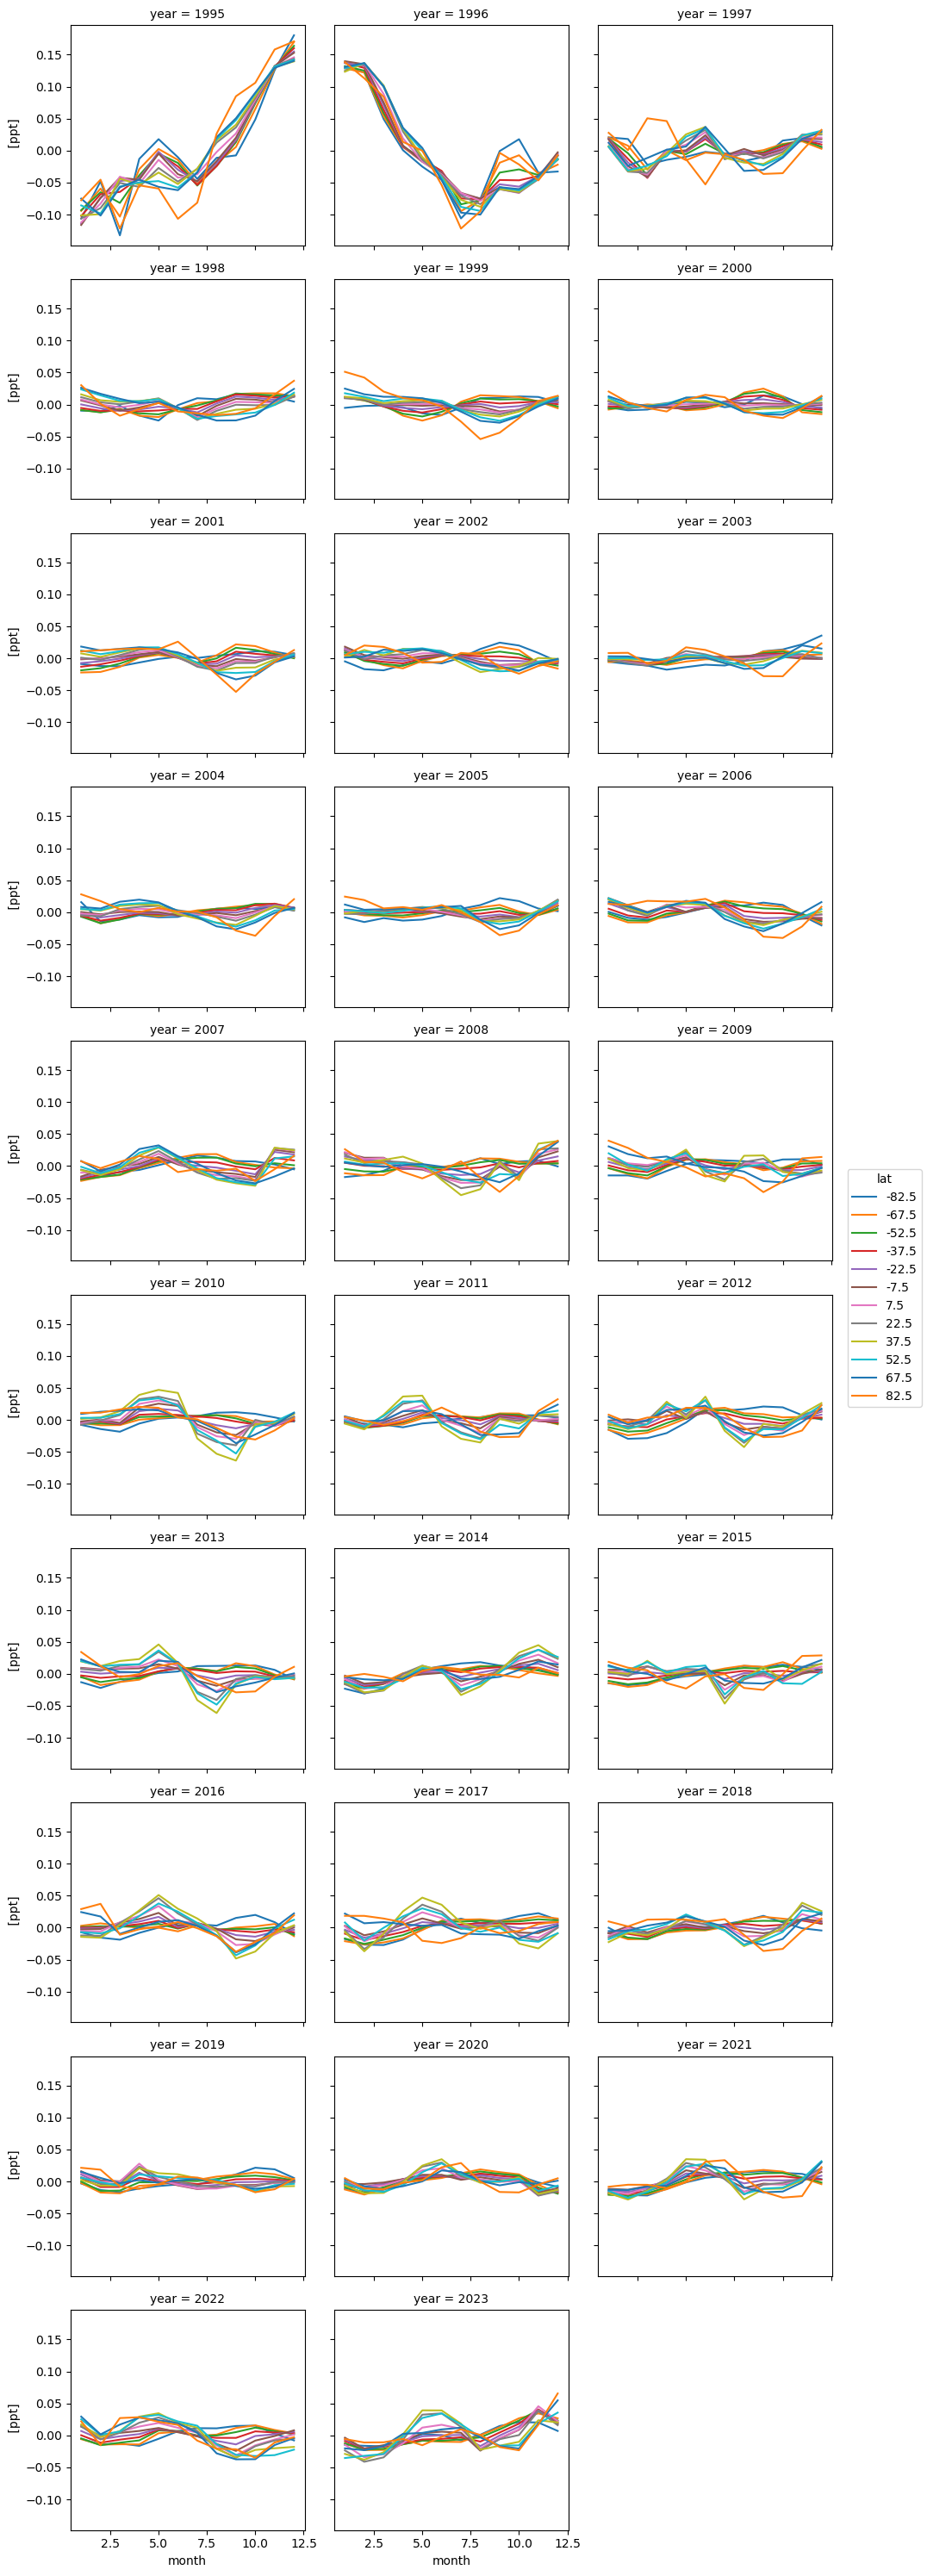

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

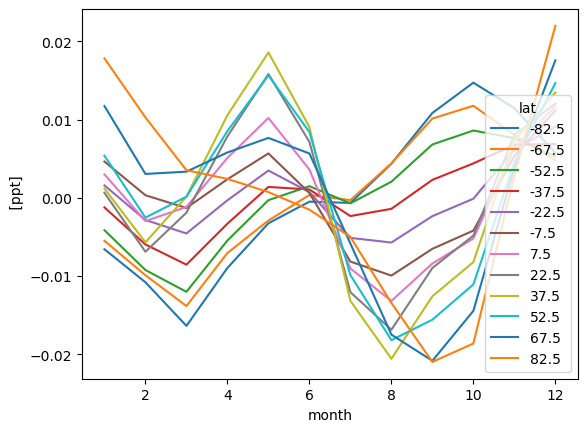

In [22]:
seasonality.plot.line(hue="lat")

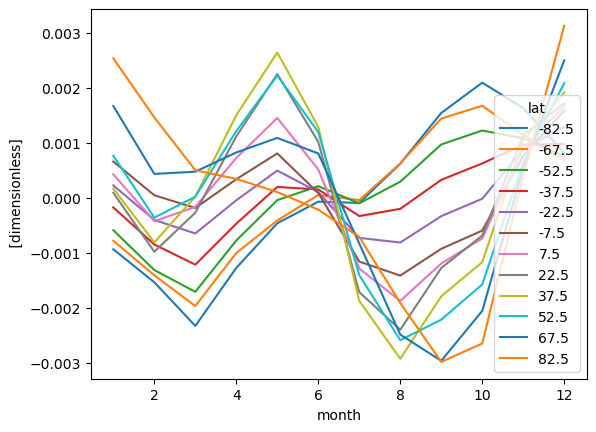

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[3.4631229771226746 3.7026958891039334 3.9743842101895113 4.190064343924795 4.378366486470264 4.581215630604556 4.782995186305364 4.991373806501488 5.225734622193355 5.4447925522977725 5.660274469124602 5.898001969829953 6.170098848487011 6.478149086000087 6.751913881787181 7.040306890022333 7.31660457543353 7.617139768968162 7.936258181604148 8.271663247590364 8.593474835654726 8.919143961143583 9.26900070016377 9.613901113175325 9.957837213171052 10.281361859057021 10.653561674677185 11.048660714836457 11.431277131428912]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.4079144945513143] [0.38121088006618586] [0.32803681283612063] [0.25902426734783796] [0.16591949002115422] [0.07350986459476755] [-0.05027843646848017] [-0.17966488611429515] [-0.28732054111144506] [-0.3355734244310076] [-0.3569405173005223] [-0.35110224884761926]]
Units,ppt
Magnitude,[[-0.5268536692887996] [-0.5255318825237465] [-0.47377527548868265] [-0.46274172921606177] [-0.4028843032667429] [-0.3943521096226741] [-0.4018561199394775] [-0.39513027256083033] [-0.42799276933163727] [-0.4311443693212688] [-0.44665384828639076] [-0.4593226365762061] [-0.47560397981591074] [-0.5184542882134794] [-0.5321067318215438] [-0.5478900198083761] [-0.521766020995275] [-0.5408121827770037] [-0.5777188586999328] [-0.5737321803054596] [-0.5498445217639079] [-0.5714290513260026] [-0.6017812365072408] [-0.5698882234392172] [-0.5720554051146591] [-0.5652992224480415] [-0.609971857044052] [-0.636980673918009] [-0.6588197431957152]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.0009374904945895058 -0.0015384137021245954 -0.002332577145107329 -0.001276841017580687 -0.00046394329141771664 -7.031058733539811e-05 -9.358843702881742e-05 0.0006208165569500302 0.0015442980709967893 0.002096513000250711 0.0016324560860546543 0.0008190627022541567] [-0.0007828728498239113 -0.0014098785841509826 -0.001971250340893129 -0.001005013455331382 -0.00041376661493290834 5.100807109508094e-05 -4.2559484439744216e-05 0.0006266381791254917 0.0014421683675666767 0.0016759218013614272 0.0011461864213432274 0.0006834019689053872] [-0.0005903000618256291 -0.0013152802686216738 -0.0017122179276627795 -0.0007774394366563172 -4.2765496836707465e-05 0.0002112151850158858 -0.00010093868474574516 0.00029300934616626216 0.000970868514935305 0.0012248055159887073 0.0010852092585837056 0.0007538178872416803] [-0.00017556499558693268 -0.0008499167590814211 -0.0012176161533118466 -0.0004709536780161206 0.0001976791891078888 0.0001517398648856762 -0.00033284763481122593 -0.0002009580990868208 0.00032643655535572255 0.0006258633706189415 0.0009670810624540861 0.0009790413258219566] [0.0002252984452219716 -0.00040377479594756906 -0.0006494527304190421 -4.5302388872089614e-05 0.0004961760480621366 0.00010335478298795406 -0.0007302474589478728 -0.0008148906508435331 -0.00033429330810384 -1.7042360071878706e-05 0.0008767006924189068 0.0012934577475931948] [0.0006604474976962634 4.628907626976735e-05 -0.00018560926092153966 0.00033788666558444294 0.0008078642694823115 8.706098521620037e-05 -0.0011616858460937363 -0.0014166925006157073 -0.0009290012619036773 -0.0005972287936694432 0.0007622350805803777 0.0015884180613612157] [0.00042599544371661583 -0.0004250280235534897 -0.00016647813330822458 0.0007261580529894526 0.001453831056878005 0.0005150103254090309 -0.0012878829362798264 -0.0018778064893486845 -0.0011966461245479178 -0.0007407875833826549 0.0009072724550510234 0.001666345752493194] [9.051081318837445e-05 -0.0009822477311407826 -0.00027111887310531476 0.0011187423163504192 0.0022529651479316327 0.0010177455624824255 -0.0017184209964433309 -0.002403102150563869 -0.001278126909639676 -0.0006875045375745772 0.0011426267696512662 0.001717911575109635] [0.00016719384670939349 -0.0008110837065497562 2.1627551541953098e-05 0.0015036503602600384 0.002645596514685735 0.001288792249856959 -0.001876810498568916 -0.002931306089586539 -0.0017931672903893467 -0.0011716445900720979 0.0010398574065841138 0.0019172729159575776] [0.0007657679509402256 -0.0003615374289651295 2.0582539579498778e-05 0.0012150897168214634 0.0022285857925412027 0.0011977407810997553 -0.0014073644024165323 -0.0025927074731974097 -0.0022193799475318937 -0.0015777354470157983 0.0006433929001558774 0.002087543856135787] [0.0016709415339739892 0.00043462069470628526 0.00047528112502716574 0.0008253765911603089 0.0010901529153139516 0.0008066754752468356 -0.0008332810516704729 -0.0024915254527770126 -0.0029682184938464745 -0.0020589205070045617 0.0005466369477992968 0.00250224204627049] [0.002538577007009221 0.0014632377156374706 0.0005023346909856953 0.00034463534119117686 0.00010385509440635883 -0.00021625969548142655 -0.0007128653558139016 -0.001915453863582401 -0.0029887360498747077 -0.002653178475876541 0.0004042649756524741 0.0031295716118012345]]
Units,dimensionless
